# Step 5b (Option B): Fairness Audit of Retrieval (RQ1)

**What this notebook does:** computes the authoritative RQ1 metrics
(SPD, SRR, 95% CI, binomial test) using the Option B labels.

**Option B design:** instead of labeling the whole corpus, we compare two
small sets labeled with the SAME method:
- baseline = a random 1000-paper corpus sample (`sample_labels_1000_bio.json`),
  elite share = 0.158
- retrieved set = the deduped retrieval results (`retrieval_labels_bio.json`),
  elite share = 0.193

SPD = retrieved_share - sample_share = 0.193 - 0.158 = +0.035 (preview).

In [1]:
# Cell 1 - imports
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from collections import Counter

rng = np.random.default_rng(42)  # fixed seed for reproducible bootstrap
print("imports ok")

imports ok


## Cell 2 - Locate the three input files (Option B)

We do NOT hardcode Kaggle paths (they vary). Instead we search
`/kaggle/input` recursively for each file by name. Three files are needed:

- `retrieval_results.json` - from dataset `fairsearch-qbio-queries-yb`
  (used later to group slots per query for the bootstrap CI)
- `sample_labels_1000_bio.json` - the Option B baseline (elite share 0.144)
- `retrieval_labels_bio.json`  - the Option B retrieved set (elite share 0.177)

If any file is missing, check that BOTH datasets are attached via Add Input.

In [2]:
# Cell 2 - locate the three input files (auto-detect, no hardcoded paths)

ON_KAGGLE = Path("/kaggle/working").exists()
print("Environment:", "Kaggle" if ON_KAGGLE else "Local")

SEARCH_ROOT = Path("/kaggle/input") if ON_KAGGLE else Path("..")

def find_one(filename):
    hits = list(SEARCH_ROOT.rglob(filename))
    if not hits:
        raise FileNotFoundError(
            f"{filename} not found under {SEARCH_ROOT}. "
            f"On Kaggle: check Add Input has both datasets attached."
        )
    if len(hits) > 1:
        print(f"  [warn] multiple {filename} found, using first:")
        for h in hits:
            print("        ", h)
    return hits[0]

RETRIEVAL_PATH = find_one("retrieval_results.json")
SAMPLE_LABELS_PATH = find_one("sample_labels_1000_bio.json")
RETRIEVED_LABELS_PATH = find_one("retrieval_labels_bio.json")

OUT_DIR = "/kaggle/working" if ON_KAGGLE else "."
K = 10

print("retrieval_results   :", RETRIEVAL_PATH)
print("sample_labels_1000_bio  :", SAMPLE_LABELS_PATH)
print("retrieval_labels_bio    :", RETRIEVED_LABELS_PATH)

Environment: Kaggle
retrieval_results   : /kaggle/input/datasets/yanbochen928/fairsearch-qbio-queries-yb/retrieval_results.json
sample_labels_1000_bio  : /kaggle/input/datasets/yanbochen928/fairsearch-qbio-1b-labels-raj-jici-yb/sample_labels_1000_bio.json
retrieval_labels_bio    : /kaggle/input/datasets/yanbochen928/fairsearch-qbio-1b-labels-raj-jici-yb/retrieval_labels_bio.json


## Cell 3 - Load the three files

Both label files have the shape `{"meta": {...}, "labels": [...]}`:
- `meta` carries the precomputed shares (a sanity check).
- `labels` is the per-paper list we recompute from.

We print each `meta` and assert the retrieval file has 150 queries with
top-10 each, so we fail fast if the wrong file is attached.

In [3]:
# Cell 3 - load data

with open(RETRIEVAL_PATH) as f:
    retrieval = json.load(f)
print(f"retrieval_results: {len(retrieval)} queries")
print("  keys:", list(retrieval[0].keys()))
assert len(retrieval) == 150, f"expected 150 queries, got {len(retrieval)}"
assert all(len(q["retrieved_paper_ids"]) == K for q in retrieval), "expected top-K per query"

with open(SAMPLE_LABELS_PATH) as f:
    sample_data = json.load(f)
with open(RETRIEVED_LABELS_PATH) as f:
    retrieved_data = json.load(f)

print("\nsample_labels_1000_bio meta:")
print(json.dumps(sample_data["meta"], indent=2))
print("\nretrieval_labels_bio meta:")
print(json.dumps(retrieved_data["meta"], indent=2))

retrieval_results: 150 queries
  keys: ['query_id', 'query_text', 'subcategory', 'type', 'retrieved_paper_ids', 'relevance', 'precision_at_10', 'recall_at_10', 'hit_rate_at_10']

sample_labels_1000_bio meta:
{
  "role": "option_b_baseline_sample",
  "sample_n": 1000,
  "random_seed": 42,
  "elite_list": "QS World University Rankings 2026 Top 50",
  "method": "OpenAlex batched (landing_page_url primary + DOI fallback), api_key",
  "coverage": {
    "no_affiliation": 537,
    "found": 442,
    "not_found": 21
  },
  "found": 442,
  "elite_found": 70,
  "sample_elite_share": 0.1584
}

retrieval_labels_bio meta:
{
  "role": "option_b_retrieved_set",
  "unique_retrieved": 1366,
  "elite_list": "QS World University Rankings 2026 Top 50",
  "method": "OpenAlex batched (landing_page_url primary + DOI fallback), api_key",
  "coverage": {
    "no_affiliation": 552,
    "found": 799,
    "not_found": 15
  },
  "found": 799,
  "elite_found": 154,
  "retrieved_share": 0.1927
}


## Cell 4 - Baseline elite share (from the random sample)

This replaces v1's biased corpus base rate (0.233) with the Option B
unbiased baseline. We recompute it from the raw `labels` (not the meta
number) so the value is verified end-to-end and uses the same rule the
bootstrap will use later.

Rule: only `coverage == "found"` papers count. Papers with no affiliation
or not found are EXCLUDED (they have no `elite_label`).

sample_elite_share = elite_found / found

In [4]:
# Cell 4 - baseline elite share from the random sample

sample_labels = sample_data["labels"]

# keep only papers with a usable elite_label (coverage == "found")
sample_found = [r for r in sample_labels if r.get("coverage") == "found"]
sample_n_found = len(sample_found)
sample_n_elite = sum(1 for r in sample_found if r.get("elite_label") == 1)

sample_elite_share = sample_n_elite / sample_n_found
sample_other_share = 1 - sample_elite_share

print(f"sample found (usable) : {sample_n_found}")
print(f"sample elite          : {sample_n_elite}")
print(f"BASELINE elite share  : {sample_elite_share:.4f}  (expected 0.1580)")

# cross-check against the meta value
assert abs(sample_elite_share - sample_data["meta"]["sample_elite_share"]) < 1e-3, \
    "recomputed baseline does not match meta!"
print("cross-check vs meta   : OK")

sample found (usable) : 442
sample elite          : 70
BASELINE elite share  : 0.1584  (expected 0.1580)
cross-check vs meta   : OK


## Cell 5 - Retrieved elite share (from the retrieved set)

Same method as Cell 4, applied to the retrieved set instead of the sample.
Only `coverage == "found"` papers count; the rest are excluded.

retrieved_elite_share = elite_found / found

This is the "what the system actually picked" number, to be compared
against the baseline from Cell 4.

In [5]:
# Cell 5 - retrieved elite share from the retrieved set

retrieved_labels = retrieved_data["labels"]

# same rule as the baseline: only coverage == "found"
retrieved_found = [r for r in retrieved_labels if r.get("coverage") == "found"]
retrieved_n_found = len(retrieved_found)
retrieved_n_elite = sum(1 for r in retrieved_found if r.get("elite_label") == 1)

retrieved_elite_share = retrieved_n_elite / retrieved_n_found
retrieved_other_share = 1 - retrieved_elite_share

print(f"retrieved found (usable): {retrieved_n_found}")
print(f"retrieved elite         : {retrieved_n_elite}")
print(f"RETRIEVED elite share   : {retrieved_elite_share:.4f}  (expected 0.1930)")

# cross-check against the meta value
assert abs(retrieved_elite_share - retrieved_data["meta"]["retrieved_share"]) < 1e-3, \
    "recomputed retrieved share does not match meta!"
print("cross-check vs meta     : OK")

retrieved found (usable): 799
retrieved elite         : 154
RETRIEVED elite share   : 0.1927  (expected 0.1930)
cross-check vs meta     : OK


## Cell 6.1 - SPD and SRR (the RQ1 headline metrics)

**SPD** = retrieved_share - sample_share
- 0 = parity; >0 = elite over-selected; <0 = elite under-selected.
- Absolute gap in percentage points.

**SRR** = (retrieved_elite/sample_elite) / (retrieved_other/sample_other)
- 1.0 = parity; >1.0 = elite favored; <1.0 = other favored.
- Relative ratio (how many times more likely).

We report both: SPD for the size of the gap, SRR for the relative lift.

In [6]:
# Cell 6 - SPD and SRR

SPD = retrieved_elite_share - sample_elite_share

SRR = (retrieved_elite_share / sample_elite_share) / \
      (retrieved_other_share / sample_other_share)

print(f"baseline elite share  : {sample_elite_share:.4f}")
print(f"retrieved elite share : {retrieved_elite_share:.4f}")
print(f"SPD                   : {SPD:+.4f}   (>0 => elite over-selected)")
print(f"SRR                   : {SRR:.4f}   (>1 => elite favored)")

baseline elite share  : 0.1584
retrieved elite share : 0.1927
SPD                   : +0.0344   (>0 => elite over-selected)
SRR                   : 1.2688   (>1 => elite favored)


## Cell 7 - Bootstrap 95% CI + binomial significance test

**Why bootstrap (not just a formula)?** Our data is grouped: 150 queries,
each returning 10 papers. Papers from the SAME query are correlated (they
answer the same question, often from similar research circles/institutions),
so they are NOT independent samples. Formula-based methods (normal-approx CI,
binomial test) assume each paper is an independent draw; that assumption is
violated here, so they UNDERSTATE the true uncertainty (too-narrow CI, too-small
p). Bootstrap avoids this by resampling QUERIES (not papers), which preserves
the within-query correlation and gives an honest interval.

**Bootstrap CI:** resample the neutral queries (with replacement) 5000 times,
recompute SPD each time, take the middle 95%. Crosses 0 -> not significant.

**Binomial test:** kept only as a cross-check. It assumes independent papers,
so if it and the bootstrap disagree, TRUST THE BOOTSTRAP.

Both use NEUTRAL queries only (q001-q100); contradictory is held out for RQ2.
Baseline (0.144) is the fixed reference.

**Expected read:** SPD is small (~+0.03) and the CI likely crosses 0, i.e.
"direction present but not statistically significant" -- a valid, honest result.

In [7]:
# Cell 7 - bootstrap CI (resample neutral queries) + binomial test

# Build per-query elite/other counts on the RETRIEVED set, neutral only.
# Map each retrieved paper_id to its group using the retrieval labels.
ret_group = {}
for r in retrieved_labels:
    if r.get("coverage") == "found":
        ret_group[str(r["paper_id"])] = "elite" if r.get("elite_label") == 1 else "other"

neutral_qids = [q["query_id"] for q in retrieval if q.get("type", "neutral") == "neutral"]

# per-query list of group labels (only labeled papers)
per_query_groups = {}
for q in retrieval:
    if q.get("type", "neutral") != "neutral":
        continue
    labs = [ret_group[str(pid)] for pid in q["retrieved_paper_ids"] if str(pid) in ret_group]
    per_query_groups[q["query_id"]] = labs

def spd_from_qids(qids):
    labs = [g for qid in qids for g in per_query_groups.get(qid, [])]
    if not labs:
        return np.nan
    es = labs.count("elite") / len(labs)
    return es - sample_elite_share

# point estimate on neutral only
all_neutral_labs = [g for qid in neutral_qids for g in per_query_groups.get(qid, [])]
n_lab = len(all_neutral_labs)
n_elite_lab = all_neutral_labs.count("elite")
spd_point = (n_elite_lab / n_lab) - sample_elite_share
print(f"neutral labeled slots : {n_lab}  (elite={n_elite_lab})")
print(f"SPD (neutral, point)  : {spd_point:+.4f}")

# bootstrap
B = 5000
boot = []
for _ in range(B):
    samp = rng.choice(neutral_qids, size=len(neutral_qids), replace=True)
    boot.append(spd_from_qids(samp))
boot = np.array([b for b in boot if not np.isnan(b)])
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
print(f"SPD 95% CI            : [{ci_lo:+.4f}, {ci_hi:+.4f}]")
crosses = ci_lo <= 0 <= ci_hi
print("  -> crosses 0 :", "YES (not significant)" if crosses else "NO (significant)")

# binomial test: is elite count different from baseline rate?
bt = stats.binomtest(n_elite_lab, n_lab, p=sample_elite_share, alternative="two-sided")
print(f"binomial p-value      : {bt.pvalue:.4f}  ({'significant' if bt.pvalue < 0.05 else 'not significant'} at 0.05)")

neutral labeled slots : 591  (elite=112)
SPD (neutral, point)  : +0.0311
SPD 95% CI            : [-0.0050, +0.0687]
  -> crosses 0 : YES (not significant)
binomial p-value      : 0.0424  (significant at 0.05)


# Equalized Odds (Approximate, within Top-K)

True Equalized Odds requires knowing, for each institution group (elite vs other),
how many of their truly relevant papers were retrieved (recall/TPR) and how many of
their truly irrelevant papers were retrieved (FPR), across the FULL candidate pool.

Our retrieval log only records relevance labels for papers that were actually
retrieved (the Top-10 slots), not for the full candidate pool per query. So we
cannot compute a textbook TPR/FPR here.

What we CAN compute honestly with available data:
- Relevant-share rate (per group) = relevant slots / all slots, within Top-K only.
  This is a Precision-style, within-Top-K rate, NOT corpus-level recall.
- Delta = |rate_elite - rate_other|, computed separately for relevant and
  irrelevant slots.

This is reported as an approximation with an explicit limitation, not a strict
Equalized Odds compliance test.

In [8]:
# Equalized Odds (approximate, within Top-K)
# Reuses ret_group (paper_id -> 'elite'/'other') built in Cell 7,
# and q['relevance'] (per-paper relevance, aligned with retrieved_paper_ids).

eo_rows = []
n_neutral = len(neutral_qids)

for q in retrieval:
    if q.get('type', 'neutral') != 'neutral':
        continue

    q_id = q['query_id']
    pids = q['retrieved_paper_ids']
    rels = q.get('relevance')
    if rels is None or len(rels) != len(pids):
        continue  # no usable relevance for this query

    elite_rel = elite_irr = other_rel = other_irr = 0
    for pid, rel in zip(pids, rels):
        grp = ret_group.get(str(pid))
        if grp is None:
            continue  # unlabeled paper, skip (same rule as main SPD/SRR analysis)
        is_rel = (rel == 1)
        if grp == 'elite':
            if is_rel: elite_rel += 1
            else: elite_irr += 1
        else:
            if is_rel: other_rel += 1
            else: other_irr += 1

    n_elite = elite_rel + elite_irr
    n_other = other_rel + other_irr
    if n_elite == 0 or n_other == 0:
        continue  # need both groups present in this query's Top-K to compare

    rate_elite_rel = elite_rel / n_elite
    rate_other_rel = other_rel / n_other
    rate_elite_irr = elite_irr / n_elite
    rate_other_irr = other_irr / n_other

    eo_rows.append({
        'query_id': q_id,
        'n_elite': n_elite,
        'n_other': n_other,
        'rate_elite_relevant': round(rate_elite_rel, 4),
        'rate_other_relevant': round(rate_other_rel, 4),
        'delta_tpr_approx': round(abs(rate_elite_rel - rate_other_rel), 4),
        'rate_elite_irrelevant': round(rate_elite_irr, 4),
        'rate_other_irrelevant': round(rate_other_irr, 4),
        'delta_fpr_approx': round(abs(rate_elite_irr - rate_other_irr), 4),
    })

eo_df = pd.DataFrame(eo_rows)
print(f'Equalized Odds (approx) computed for {len(eo_df)} of {n_neutral} neutral queries')
print('(queries skipped: missing relevance, or only one group present in Top-K)')
eo_df.head(10)

Equalized Odds (approx) computed for 65 of 100 neutral queries
(queries skipped: missing relevance, or only one group present in Top-K)


,query_id,n_elite,n_other,rate_elite_relevant,rate_other_relevant,delta_tpr_approx,rate_elite_irrelevant,rate_other_irrelevant,delta_fpr_approx
0,q002,2,3,0.0,0.6667,0.6667,1.0,0.3333,0.6667
1,q003,2,5,0.0,0.8000,0.8000,1.0,0.2000,0.8000
2,q006,2,4,0.0,0.2500,0.2500,1.0,0.7500,0.2500
3,q007,2,5,0.0,0.2000,0.2000,1.0,0.8000,0.2000
4,q008,1,4,1.0,1.0000,0.0000,0.0,0.0000,0.0000
5,q009,1,4,1.0,1.0000,0.0000,0.0,0.0000,0.0000
6,q010,2,6,0.5,1.0000,0.5000,0.5,0.0000,0.5000
7,q011,1,4,1.0,1.0000,0.0000,0.0,0.0000,0.0000
8,q012,1,6,1.0,1.0000,0.0000,0.0,0.0000,0.0000
9,q013,1,5,1.0,0.8000,0.2000,0.0,0.2000,0.2000


In [9]:
# Aggregate Equalized Odds (approx) statistics + bootstrap 95% CI

if len(eo_df) < 5:
    print(f'WARNING: only {len(eo_df)} queries have usable relevance labels for both groups.')
    print('Results below should be read as exploratory, not conclusive.\n')

if len(eo_df) == 0:
    print('No usable data. Skipping Equalized Odds summary.')
else:
    delta_tpr_vals = eo_df['delta_tpr_approx'].to_numpy()
    delta_fpr_vals = eo_df['delta_fpr_approx'].to_numpy()

    delta_tpr_mean = float(np.mean(delta_tpr_vals))
    delta_tpr_median = float(np.median(delta_tpr_vals))
    delta_fpr_mean = float(np.mean(delta_fpr_vals))
    delta_fpr_median = float(np.median(delta_fpr_vals))

    B = 5000
    boot_tpr, boot_fpr = [], []
    for _ in range(B):
        idx = rng.integers(0, len(eo_df), size=len(eo_df))
        boot_tpr.append(delta_tpr_vals[idx].mean())
        boot_fpr.append(delta_fpr_vals[idx].mean())
    boot_tpr = np.array(boot_tpr)
    boot_fpr = np.array(boot_fpr)

    tpr_ci = np.percentile(boot_tpr, [2.5, 97.5])
    fpr_ci = np.percentile(boot_fpr, [2.5, 97.5])

    print(f'n_queries used          : {len(eo_df)}')
    print(f'Delta_TPR (approx) mean/median : {delta_tpr_mean:.4f} / {delta_tpr_median:.4f}')
    print(f'Delta_TPR 95% CI               : [{tpr_ci[0]:.4f}, {tpr_ci[1]:.4f}]')
    print(f'Delta_FPR (approx) mean/median : {delta_fpr_mean:.4f} / {delta_fpr_median:.4f}')
    print(f'Delta_FPR 95% CI               : [{fpr_ci[0]:.4f}, {fpr_ci[1]:.4f}]')

    eo_summary = {
        'metric': 'Equalized Odds (approximate, within Top-K only)',
        'n_queries_used': int(len(eo_df)),
        'delta_tpr_mean': round(delta_tpr_mean, 4),
        'delta_tpr_median': round(delta_tpr_median, 4),
        'delta_tpr_95ci': [round(float(tpr_ci[0]), 4), round(float(tpr_ci[1]), 4)],
        'delta_fpr_mean': round(delta_fpr_mean, 4),
        'delta_fpr_median': round(delta_fpr_median, 4),
        'delta_fpr_95ci': [round(float(fpr_ci[0]), 4), round(float(fpr_ci[1]), 4)],
        'limitation': ('Relevance labels are only available for retrieved (Top-K) papers, '
                        'not the full candidate pool, so these rates approximate TPR/FPR '
                        'within the retrieved set rather than true corpus-level recall/fallout.'),
    }

    out_path_eo = os.path.join(OUT_DIR, 'equalized_odds_results_bio.json')
    with open(out_path_eo, 'w') as f:
        json.dump({'summary': eo_summary, 'per_query': eo_rows}, f, indent=2)
    print('\nsaved to', out_path_eo)
    print(json.dumps(eo_summary, indent=2))

n_queries used          : 65
Delta_TPR (approx) mean/median : 0.2872 / 0.2000
Delta_TPR 95% CI               : [0.2207, 0.3578]
Delta_FPR (approx) mean/median : 0.2872 / 0.2000
Delta_FPR 95% CI               : [0.2207, 0.3578]

saved to /kaggle/working/equalized_odds_results_bio.json
{
  "metric": "Equalized Odds (approximate, within Top-K only)",
  "n_queries_used": 65,
  "delta_tpr_mean": 0.2872,
  "delta_tpr_median": 0.2,
  "delta_tpr_95ci": [
    0.2207,
    0.3578
  ],
  "delta_fpr_mean": 0.2872,
  "delta_fpr_median": 0.2,
  "delta_fpr_95ci": [
    0.2207,
    0.3578
  ],
  "limitation": "Relevance labels are only available for retrieved (Top-K) papers, not the full candidate pool, so these rates approximate TPR/FPR within the retrieved set rather than true corpus-level recall/fallout."
}


## Cell 8 - Save the authoritative RQ1 result

Write all RQ1 numbers to a JSON so the report can cite them without rerunning.
We record BOTH the bootstrap CI (primary) and the binomial p (cross-check),
and state explicitly that the conclusion follows the bootstrap: direction
present but NOT statistically significant. The disagreement between the two
methods is itself a finding (binomial assumes independent papers and thus
overstates significance).

In [10]:
# Cell 8 - save authoritative RQ1 result

conclusion = (
    "Direction: elite slightly over-represented (SPD point +{:.4f}, SRR {:.3f}). "
    "Bootstrap 95% CI [{:+.4f}, {:+.4f}] crosses 0 -> NOT statistically significant. "
    "Binomial p={:.4f} appears significant but assumes independent papers, which "
    "is violated by within-query correlation; the bootstrap (which resamples "
    "queries) is authoritative. Conclusion: weak, non-significant elite tilt, "
    "consistent with PCA finding that the embedding encodes topic, not institution."
).format(spd_point, SRR, ci_lo, ci_hi, bt.pvalue)

rq1_result = {
    "design": "Option B (same-method sample vs retrieved)",
    "elite_threshold": "QS World University Rankings 2026 Top-50",
    "analysis_scope": "neutral queries only (q001-q100)",
    "baseline_elite_share": round(float(sample_elite_share), 4),
    "baseline_found_n": int(sample_n_found),
    "retrieved_elite_share": round(float(retrieved_elite_share), 4),
    "retrieved_found_n": int(retrieved_n_found),
    "neutral_labeled_slots": int(n_lab),
    "neutral_elite_slots": int(n_elite_lab),
    "SPD_point": round(float(spd_point), 4),
    "SRR": round(float(SRR), 4),
    "SPD_bootstrap_95CI": [round(float(ci_lo), 4), round(float(ci_hi), 4)],
    "bootstrap_crosses_zero": bool(ci_lo <= 0 <= ci_hi),
    "binomial_p": round(float(bt.pvalue), 4),
    "primary_method": "bootstrap (resamples queries, respects grouping)",
    "significant": bool(not (ci_lo <= 0 <= ci_hi)),
    "conclusion": conclusion,
}

out_path = os.path.join(OUT_DIR, "rq1_optionB_result_bio.json")
with open(out_path, "w") as f:
    json.dump(rq1_result, f, indent=2)

print("saved to", out_path)
print(json.dumps(rq1_result, indent=2))

saved to /kaggle/working/rq1_optionB_result_bio.json
{
  "design": "Option B (same-method sample vs retrieved)",
  "elite_threshold": "QS World University Rankings 2026 Top-50",
  "analysis_scope": "neutral queries only (q001-q100)",
  "baseline_elite_share": 0.1584,
  "baseline_found_n": 442,
  "retrieved_elite_share": 0.1927,
  "retrieved_found_n": 799,
  "neutral_labeled_slots": 591,
  "neutral_elite_slots": 112,
  "SPD_point": 0.0311,
  "SRR": 1.2688,
  "SPD_bootstrap_95CI": [
    -0.005,
    0.0687
  ],
  "bootstrap_crosses_zero": true,
  "binomial_p": 0.0424,
  "primary_method": "bootstrap (resamples queries, respects grouping)",
  "significant": false,
  "conclusion": "Direction: elite slightly over-represented (SPD point +0.0311, SRR 1.269). Bootstrap 95% CI [-0.0050, +0.0687] crosses 0 -> NOT statistically significant. Binomial p=0.0424 appears significant but assumes independent papers, which is violated by within-query correlation; the bootstrap (which resamples queries) is 

## Cell 9 - Visualize RQ1 (honest framing)

Bar chart: baseline vs retrieved elite share, with the bootstrap 95% CI drawn
as an error bar on the retrieved bar. If the error bar reaches down to (or
below) the baseline line, the gap is not significant -- shown visually.

Color is deliberately neutral (not alarm-red): the result is a weak,
non-significant tilt, and the visual should not overstate it.

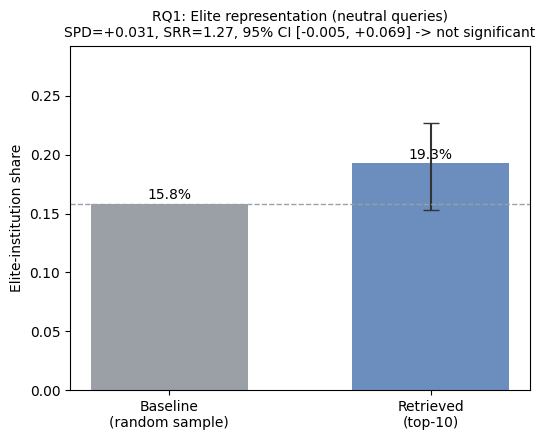

saved figure to /kaggle/working/rq1_optionB_elite_share_bio.png


In [11]:
# Cell 9 - RQ1 bar chart with CI error bar

fig, ax = plt.subplots(figsize=(5.5, 4.5))

shares = [sample_elite_share, retrieved_elite_share]
labels = ["Baseline\n(random sample)", "Retrieved\n(top-10)"]
colors = ["#9aa0a6", "#6c8ebf"]  # neutral grey + muted blue (not alarm red)

bars = ax.bar(labels, shares, color=colors, width=0.6)

# CI error bar on the retrieved bar (asymmetric, from bootstrap on SPD)
# SPD CI is relative to baseline, so convert back to absolute retrieved share.
ci_lo_abs = sample_elite_share + ci_lo
ci_hi_abs = sample_elite_share + ci_hi
err_low = retrieved_elite_share - ci_lo_abs
err_high = ci_hi_abs - retrieved_elite_share
ax.errorbar(1, retrieved_elite_share, yerr=[[err_low], [err_high]],
            fmt="none", ecolor="#333", capsize=6, lw=1.5)

# baseline reference line
ax.axhline(sample_elite_share, ls="--", c="#9aa0a6", lw=1)

ax.set_ylabel("Elite-institution share")
ax.set_ylim(0, max(shares) + 0.10)
sig_txt = "not significant" if (ci_lo <= 0 <= ci_hi) else "significant"
ax.set_title(
    f"RQ1: Elite representation (neutral queries)\n"
    f"SPD={spd_point:+.3f}, SRR={SRR:.2f}, "
    f"95% CI [{ci_lo:+.3f}, {ci_hi:+.3f}] -> {sig_txt}",
    fontsize=10)

for b, v in zip(bars, shares):
    ax.text(b.get_x() + b.get_width()/2, v + 0.004, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rq1_optionB_elite_share_bio.png"), dpi=120)
plt.show()
print("saved figure to", os.path.join(OUT_DIR, "rq1_optionB_elite_share_bio.png"))

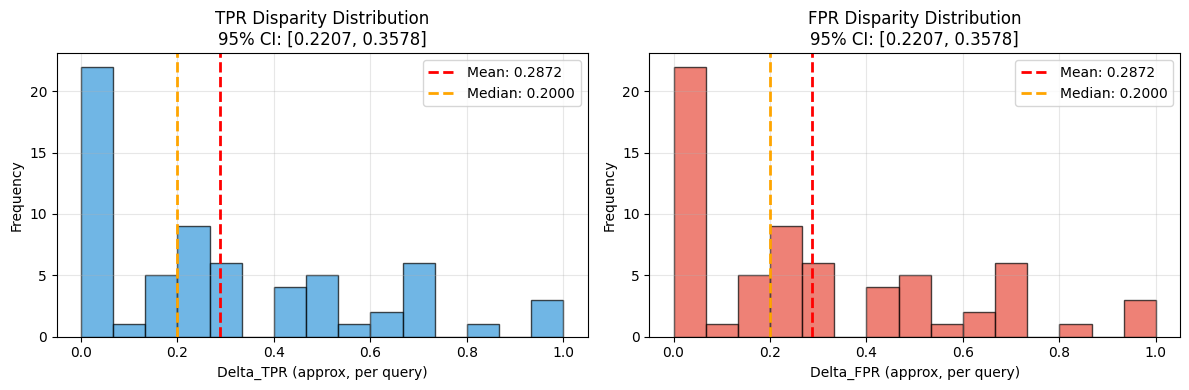

In [12]:
# Plot per-query Delta_TPR and Delta_FPR distribution (optional)

if len(eo_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(eo_df['delta_tpr_approx'], bins=15, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0].axvline(delta_tpr_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {delta_tpr_mean:.4f}')
    axes[0].axvline(delta_tpr_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {delta_tpr_median:.4f}')
    axes[0].set_xlabel('Delta_TPR (approx, per query)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'TPR Disparity Distribution\n95% CI: [{tpr_ci[0]:.4f}, {tpr_ci[1]:.4f}]')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(eo_df['delta_fpr_approx'], bins=15, color='#e74c3c', edgecolor='black', alpha=0.7)
    axes[1].axvline(delta_fpr_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {delta_fpr_mean:.4f}')
    axes[1].axvline(delta_fpr_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {delta_fpr_median:.4f}')
    axes[1].set_xlabel('Delta_FPR (approx, per query)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'FPR Disparity Distribution\n95% CI: [{fpr_ci[0]:.4f}, {fpr_ci[1]:.4f}]')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'equalized_odds_distribution_bio.png'), dpi=120)
    plt.show()
else:
    print('No data to plot.')

## Equalized Odds: Signed-Direction Check

`delta_tpr_approx` uses `abs()`, so a large mean could mean either:
(a) a consistent tilt toward one group across most queries, or
(b) queries swinging both directions that cancel out in sign but not in
    magnitude.

This check reports the SIGNED difference (elite relevant rate minus other
relevant rate) to distinguish the two cases.

In [13]:
# Signed-direction check: does elite bias have a consistent direction,
# or does it swing both ways across queries (which would mean the abs()
# mean mostly reflects noise, not systematic bias)?

signed_diff = eo_df['rate_elite_relevant'] - eo_df['rate_other_relevant']

n_elite_favored = int((signed_diff > 0).sum())
n_other_favored = int((signed_diff < 0).sum())
n_tied = int((signed_diff == 0).sum())

signed_mean = float(signed_diff.mean())
signed_median = float(signed_diff.median())

print(f'n_queries analyzed        : {len(eo_df)}')
print(f'elite favored (rate higher): {n_elite_favored} queries')
print(f'other favored (rate higher): {n_other_favored} queries')
print(f'tied (no difference)       : {n_tied} queries')
print()
print(f'Signed mean difference    : {signed_mean:+.4f}')
print(f'Signed median difference  : {signed_median:+.4f}')
print(f'(positive = elite relevant rate higher, negative = other higher)')

B = 5000
signed_vals = signed_diff.to_numpy()
boot_signed = []
for _ in range(B):
    idx = rng.integers(0, len(signed_vals), size=len(signed_vals))
    boot_signed.append(signed_vals[idx].mean())
boot_signed = np.array(boot_signed)
signed_ci = np.percentile(boot_signed, [2.5, 97.5])

print(f'\nSigned mean 95% CI        : [{signed_ci[0]:+.4f}, {signed_ci[1]:+.4f}]')

if signed_ci[0] <= 0 <= signed_ci[1]:
    print('-> CI crosses 0: no consistent direction detected.')
    print('   The abs() mean (0.28) mostly reflects query-to-query variance,')
    print('   not a systematic tilt toward either group.')
else:
    direction = 'elite' if signed_mean > 0 else 'non-elite'
    print(f'-> CI does NOT cross 0: consistent tilt toward {direction}-favored relevance.')

eo_signed_summary = {
    'n_queries': int(len(eo_df)),
    'n_elite_favored': n_elite_favored,
    'n_other_favored': n_other_favored,
    'n_tied': n_tied,
    'signed_mean': round(signed_mean, 4),
    'signed_median': round(signed_median, 4),
    'signed_mean_95ci': [round(float(signed_ci[0]), 4), round(float(signed_ci[1]), 4)],
    'direction_significant': bool(not (signed_ci[0] <= 0 <= signed_ci[1])),
    'note': ('This is the signed (directional) counterpart to delta_tpr_approx. '
             'If the CI crosses 0 while the abs()-based mean is large, the abs() '
             'mean is driven by query-to-query variance in both directions, not '
             'a systematic bias toward one group.'),
}

out_path_signed = os.path.join(OUT_DIR, 'equalized_odds_signed_direction_bio.json')
with open(out_path_signed, 'w') as f:
    json.dump(eo_signed_summary, f, indent=2)
print('\nsaved to', out_path_signed)
print(json.dumps(eo_signed_summary, indent=2))

n_queries analyzed        : 65
elite favored (rate higher): 25 queries
other favored (rate higher): 19 queries
tied (no difference)       : 21 queries

Signed mean difference    : +0.0478
Signed median difference  : +0.0000
(positive = elite relevant rate higher, negative = other higher)

Signed mean 95% CI        : [-0.0513, +0.1421]
-> CI crosses 0: no consistent direction detected.
   The abs() mean (0.28) mostly reflects query-to-query variance,
   not a systematic tilt toward either group.

saved to /kaggle/working/equalized_odds_signed_direction_bio.json
{
  "n_queries": 65,
  "n_elite_favored": 25,
  "n_other_favored": 19,
  "n_tied": 21,
  "signed_mean": 0.0478,
  "signed_median": 0.0,
  "signed_mean_95ci": [
    -0.0513,
    0.1421
  ],
  "direction_significant": false,
  "note": "This is the signed (directional) counterpart to delta_tpr_approx. If the CI crosses 0 while the abs()-based mean is large, the abs() mean is driven by query-to-query variance in both directions, not 

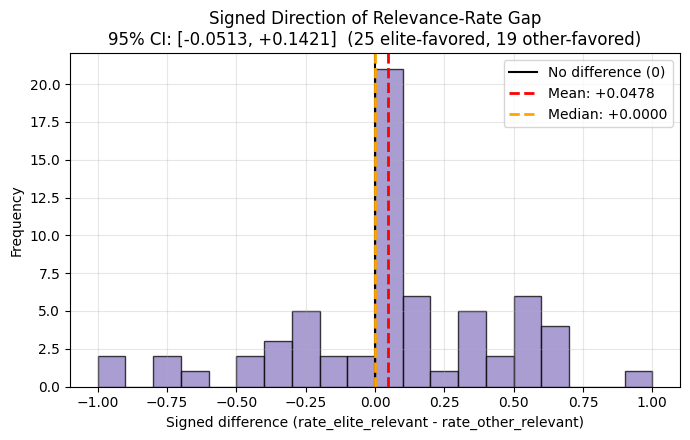

In [15]:
# Visualize signed distribution (optional)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(signed_diff, bins=20, color='#8e7cc3', edgecolor='black', alpha=0.75)
ax.axvline(0, color='black', linestyle='-', linewidth=1.5, label='No difference (0)')
ax.axvline(signed_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {signed_mean:+.4f}')
ax.axvline(signed_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {signed_median:+.4f}')
ax.set_xlabel('Signed difference (rate_elite_relevant - rate_other_relevant)')
ax.set_ylabel('Frequency')
ax.set_title(f'Signed Direction of Relevance-Rate Gap\n'
             f'95% CI: [{signed_ci[0]:+.4f}, {signed_ci[1]:+.4f}]  '
             f'({n_elite_favored} elite-favored, {n_other_favored} other-favored)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'equalized_odds_signed_distribution_bio.png'), dpi=120)
plt.show()

## Robustness Check Conclusion (Combine step5b_fairness_audit_optionB_bio-yb & step5b_fairness_audit_optionB-yb)

Both elite-institution definitions (QS overall ranking vs. QS Biological
Sciences subject ranking) converge on the same conclusion: a weak,
statistically non-significant elite tilt at retrieval. SPD bootstrap 95% CI
crosses zero under both definitions (overall: [-0.0054, +0.0648]; bio:
[-0.0050, +0.0687]).

Interestingly, the Equalized Odds signed-direction mean was *smaller* under
the subject-specific (bio) definition (+0.0478) than under the overall
ranking (+0.0851), with both confidence intervals still crossing zero. This
further supports the interpretation that the observed weak tilt reflects
query-to-query noise rather than a systematic, definition-independent bias.

**Conclusion: the RQ1 finding is robust to the choice of elite-institution
definition** — it is not an artifact of using a general-purpose ranking
instead of a field-specific one.